# Real World Classification

## Load data

Import the necessary libraries

In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [3]:
# 找出有缺失值的欄位
cols_with_missing = df.columns[df.isnull().any()].tolist()
print("有缺失值的欄位:", cols_with_missing)

# 計算並印出補值前的中位數與標準差
for col in cols_with_missing:
    print(f"[{col} - 補值前]")
    print(f"中位數 (Median): {df[col].median():.4f}")
    print(f"標準差 (Std): {df[col].std():.4f}\n")

有缺失值的欄位: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']
[SepalLengthCm - 補值前]
中位數 (Median): 6.3000
標準差 (Std): 1.0371

[SepalWidthCm - 補值前]
中位數 (Median): 2.9000
標準差 (Std): 0.3896

[PetalLengthCm - 補值前]
中位數 (Median): 5.0856
標準差 (Std): 1.5828

[PetalWidthCm - 補值前]
中位數 (Median): 1.6000
標準差 (Std): 0.7067

[BranchLength - 補值前]
中位數 (Median): 16.3000
標準差 (Std): 1.0352



## Data Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


In [6]:
cols_with_missing = [
    'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength'
]

print("=== 補值後的統計量 (After Imputation) ===")
for col in cols_with_missing:
    median_val = df[col].median()
    std_val = df[col].std()
    print(f"[{col}] 中位數 (Median): {median_val:.4f}, 標準差 (Std): {std_val:.4f}")

=== 補值後的統計量 (After Imputation) ===
[SepalLengthCm] 中位數 (Median): 6.3000, 標準差 (Std): 1.0093
[SepalWidthCm] 中位數 (Median): 2.9000, 標準差 (Std): 0.3724
[PetalLengthCm] 中位數 (Median): 5.0357, 標準差 (Std): 1.5150
[PetalWidthCm] 中位數 (Median): 1.7000, 標準差 (Std): 0.6946
[BranchLength] 中位數 (Median): 16.3000, 標準差 (Std): 1.0110


## Data Exploration

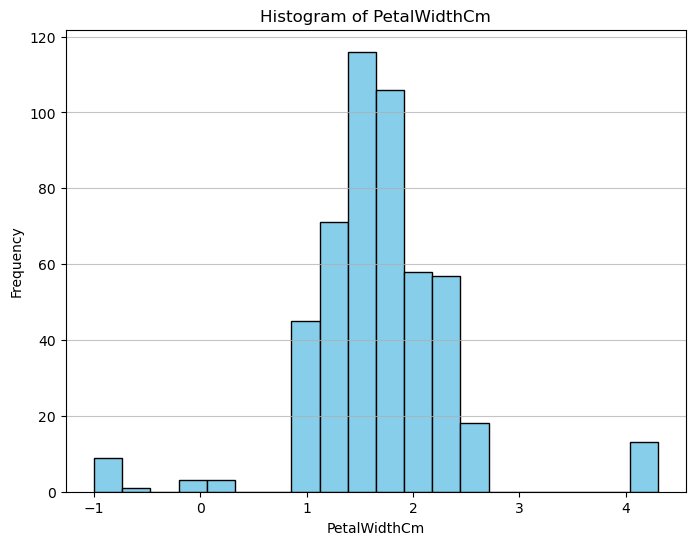

In [7]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
plt.figure(figsize=(8, 6))
plt.hist(df['PetalWidthCm'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [8]:
exclude_cols = ['PetalWidthCm', 'Species', 'Id']
features_to_check = [col for col in df.columns if col not in exclude_cols]

X_features = df[features_to_check]
y_target = df['PetalWidthCm']

correlations = r_regression(X_features, y_target)

max_corr_idx = np.argmax(correlations)
max_corr_feature = features_to_check[max_corr_idx]
max_corr_value = correlations[max_corr_idx]

print(f"與 PetalWidthCm 有最大正相關的特徵是: {max_corr_feature}")
print(f"Pearson 相關係數為: {max_corr_value:.4f}")

與 PetalWidthCm 有最大正相關的特徵是: PetalWidthCompactness
Pearson 相關係數為: 0.9917


與 PetalWidthCm 有最強負相關的前 5 個特徵是:
1. SepalWidthMajorAxis (Pearson 相關係數: -0.0964)
2. SepalGlossIndex (Pearson 相關係數: -0.0952)
3. SepalWidthCompactness (Pearson 相關係數: -0.0885)
4. SepalWidthCurvature (Pearson 相關係數: -0.0813)
5. SepalWidthMinorAxis (Pearson 相關係數: -0.0744)


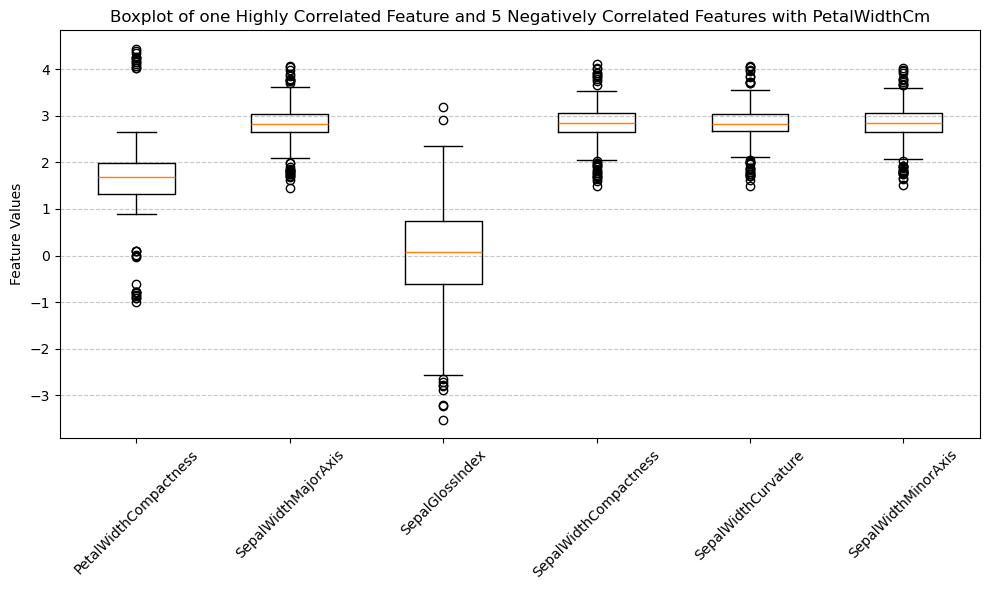

In [15]:
feature_corr_pairs = list(zip(features_to_check, correlations))

feature_corr_pairs.sort(key=lambda x: x[1])

print("與 PetalWidthCm 有最強負相關的前 5 個特徵是:")
for i in range(5):
    feature_name = feature_corr_pairs[i][0]
    corr_value = feature_corr_pairs[i][1]
    print(f"{i+1}. {feature_name} (Pearson 相關係數: {corr_value:.4f})")

features_to_plot = [
    'PetalWidthCompactness',  # 4(b) 最大正相關
    'SepalWidthMajorAxis',    # 4(c) 最強負相關 1
    'SepalGlossIndex',        # 4(c) 最強負相關 2
    'SepalWidthCompactness',  # 4(c) 最強負相關 3
    'SepalWidthCurvature',    # 4(c) 最強負相關 4
    'SepalWidthMinorAxis'     # 4(c) 最強負相關 5
]

# 設定畫布大小
plt.figure(figsize=(10, 6))

# 取出這些特徵的資料並畫箱型圖
plt.boxplot([df[feature] for feature in features_to_plot], labels=features_to_plot)

# 設定標題與標籤
plt.title('Boxplot of one Highly Correlated Feature and 5 Negatively Correlated Features with PetalWidthCm')
plt.ylabel('Feature Values')
plt.xticks(rotation=45) # 旋轉 X 軸標籤，避免字太長擠在一起
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 確保圖表顯示完整
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [16]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403308, Val loss:0.6839298451300982
250. Training loss: 0.674748717829201, Val loss:0.6839298552460086
300. Training loss: 0.6747487179798802, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692588
400. Training loss: 0.6747487179829369, Val loss:0.6839298554693627
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.683929855469365
550. Training loss: 0.6747487179829382, Val loss:0.683929855469365
600. Training loss: 0.6747487179829382, Val loss:0.683929855469365
650. Training loss: 0.6747487179829382, Val loss:0.683929855469365
700. Training loss: 0.6747487179829382, Val loss:0.683929855469365
750. Training loss: 0.6747487179829382, Val loss:0.68392

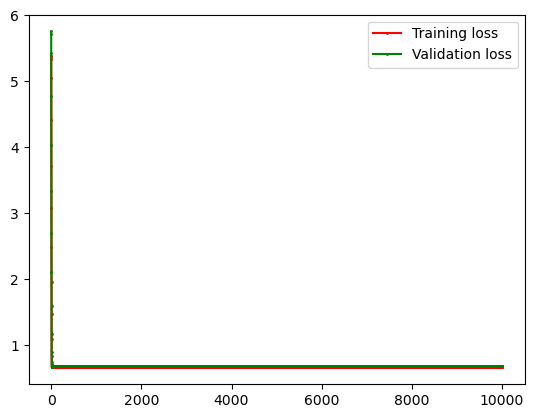

Model parameters (weights): [[-0.01249206]
 [ 0.02228109]
 [ 0.00731174]
 [ 0.02160094]
 [ 0.03647292]
 [ 0.01868654]
 [ 0.01769178]
 [ 0.01789019]
 [ 0.01923883]
 [ 0.02027882]
 [ 0.01914643]
 [ 0.02013799]
 [ 0.02095232]
 [ 0.00458568]
 [ 0.00311998]
 [ 0.00605684]
 [ 0.00705284]
 [ 0.00742952]
 [ 0.00627274]
 [ 0.02328098]
 [ 0.02385686]
 [ 0.02565637]
 [ 0.02391417]
 [ 0.02520387]
 [ 0.02375411]
 [ 0.03462815]
 [ 0.03522777]
 [ 0.03662822]
 [ 0.03649798]
 [ 0.036714  ]
 [ 0.03671077]
 [-0.01304758]
 [ 0.00456383]
 [-0.00644573]
 [-0.00238571]
 [-0.00519696]
 [-0.00335385]
 [-0.0124363 ]
 [-0.02754184]
 [-0.00523545]
 [-0.00983527]
 [-0.0041134 ]
 [-0.01539004]
 [-0.00700335]
 [-0.0017571 ]
 [-0.00552268]
 [-0.00863107]
 [-0.00523874]
 [-0.01145154]
 [-0.00881981]
 [-0.00133932]
 [-0.00757033]
 [-0.00632656]
 [-0.0080036 ]
 [-0.00210421]
 [-0.00160616]
 [-0.00839356]
 [-0.01317914]
 [-0.00861225]
 [-0.01061584]
 [-0.01525315]
 [-0.00042755]
 [ 0.00442472]
 [-0.01255564]
 [-0.0094437

In [26]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=100)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


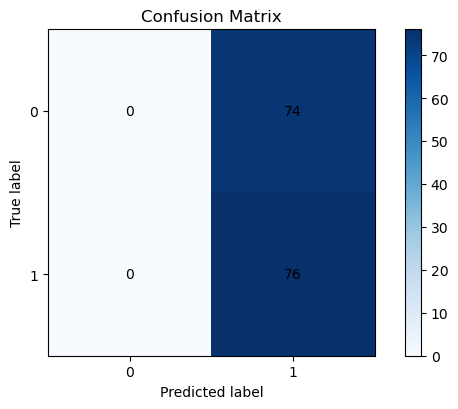

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.6725663716814159}

In [27]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)